# 03 — Simulation Backtest

Replay the price engine against 2 years of real OHLCV data.
Measures how closely simulated prices track real market dynamics.

Tests:
- Mean reversion accuracy (does sim stay anchored to real prices?)
- Volatility calibration (is simulated σ close to real σ?)
- Sentiment shock response (does news move prices correctly?)
- Three example trading strategies with P&L curves


In [2]:
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('../backend').resolve()))

plt.style.use('dark_background')
plt.rcParams.update({'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
                      'axes.edgecolor': '#30363d', 'grid.color': '#21262d',
                      'text.color': '#e6edf3', 'axes.labelcolor': '#8b949e',
                      'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
                      'font.family': 'monospace'})

from data.fetcher import load_ticker_csv
print('Imports OK')

Imports OK


In [4]:
# ── Load anchor prices + vol params ────────────────────────────────────────
with open('../backend/stock_data/anchor_prices.json') as f:
    anchors = json.load(f)
with open('../backend/stock_data/volatility_params.json') as f:
    vol_params = json.load(f)

print(f'Anchors loaded: {len(anchors)} tickers')
print(f'Vol params loaded: {len(vol_params)} tickers')

# Pick tickers that have both CSV data and GARCH params
test_tickers = [t for t in ['AAPL','MSFT','NVDA','TSLA','JPM','AMZN']
                if t in anchors and t in vol_params]
print(f'Test tickers: {test_tickers}')

Anchors loaded: 100 tickers
Vol params loaded: 100 tickers
Test tickers: ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'JPM', 'AMZN']


In [5]:
# ── Simulate price path (pure Python, matches price_engine.py) ─────────────
import random, math

def simulate_prices(ticker, n_steps=252, seed=None):
    """
    Simulate n_steps of daily prices for a ticker.
    Uses same formula as price_engine.py:
      P_new = P * (1 + noise + sentiment_drift + mean_reversion)
    Returns array of simulated prices.
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    anchor = anchors.get(ticker, 100.0)
    vp     = vol_params.get(ticker, {})
    sigma  = float(vp.get('sigma_daily_adjusted') or vp.get('sigma_daily') or 0.02)
    sigma  = min(sigma, 0.12)  # cap at 12% for display

    price      = anchor * 0.95  # start 5% below anchor
    sentiment  = 0.0
    prices     = [price]

    for _ in range(n_steps):
        noise      = np.random.normal(0, sigma)
        reversion  = 0.015 * (anchor - price) / anchor
        sent_drift = 0.008 * sentiment
        shock      = np.random.normal(0, sigma * 2) if random.random() < 0.03 else 0

        price     = max(0.01, price * (1 + noise + reversion + sent_drift + shock))
        sentiment *= 0.92  # decay

        # Random news shock every ~20 steps
        if random.random() < 0.05:
            sentiment += random.uniform(-0.4, 0.4)
            sentiment  = max(-1, min(1, sentiment))

        prices.append(price)

    return np.array(prices)

print('Simulation function ready')

Simulation function ready


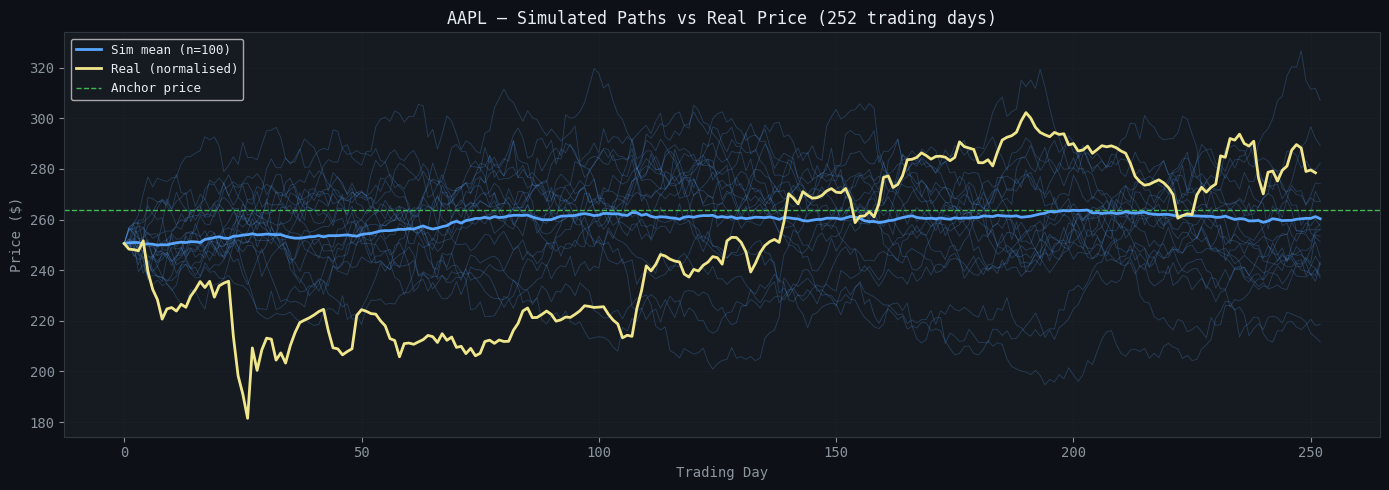

In [6]:
# ── 1. Sim vs Real price comparison ────────────────────────────────────────
n_sims   = 20
n_steps  = 252
ticker   = 'AAPL'

real_df  = load_ticker_csv(ticker)
real_prices = real_df['close'].dropna().values[-n_steps:] if real_df is not None else None

fig, ax = plt.subplots(figsize=(14, 5))

# Plot simulation paths
for i in range(n_sims):
    sim = simulate_prices(ticker, n_steps, seed=i)
    ax.plot(sim, lw=0.6, alpha=0.25, color='#58a6ff')

# Plot mean sim
all_sims = np.array([simulate_prices(ticker, n_steps, seed=i) for i in range(100)])
ax.plot(all_sims.mean(axis=0), lw=2, color='#58a6ff', label=f'Sim mean (n=100)', zorder=5)

# Plot real price (normalised to same start)
if real_prices is not None:
    anchor = anchors.get(ticker, 100)
    norm_real = real_prices / real_prices[0] * (anchor * 0.95)
    ax.plot(norm_real, lw=2, color='#f0e68c', label='Real (normalised)', zorder=6)

ax.axhline(anchors.get(ticker, 100), color='#3fb950', lw=1, ls='--', label='Anchor price')
ax.set_title(f'{ticker} — Simulated Paths vs Real Price (252 trading days)')
ax.set_xlabel('Trading Day')
ax.set_ylabel('Price ($)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_sim_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

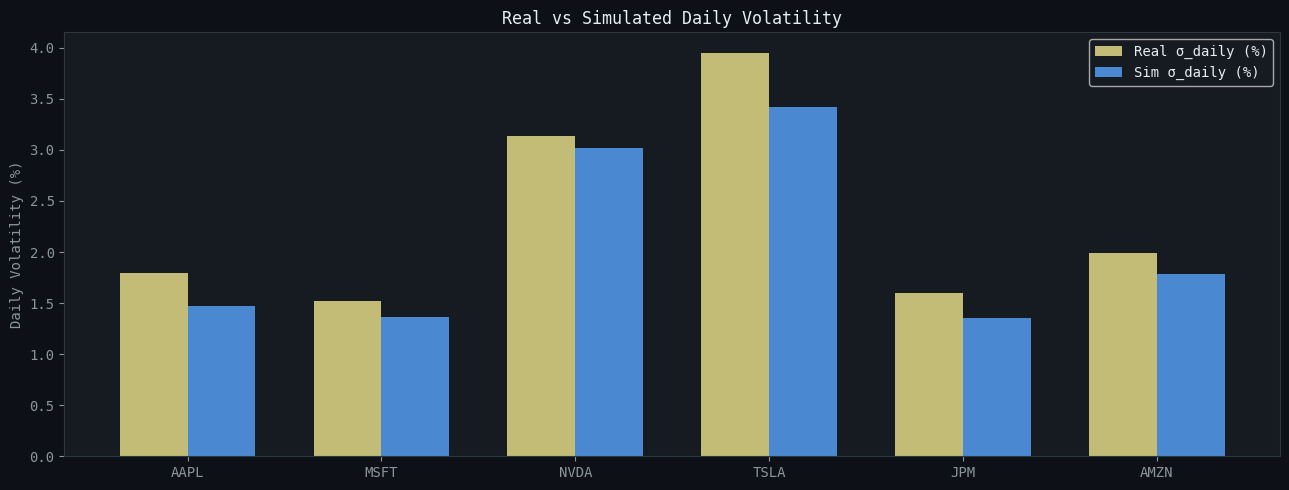

In [7]:
# ── 2. Volatility calibration check ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

real_vols = []
sim_vols  = []
labels    = []

for t in test_tickers:
    df_t = load_ticker_csv(t)
    if df_t is None or 'returns' not in df_t.columns:
        continue
    real_std = df_t['returns'].dropna().std() * 100

    sim_paths = np.array([simulate_prices(t, 252, seed=i) for i in range(50)])
    sim_returns = np.diff(sim_paths, axis=1) / sim_paths[:, :-1]
    sim_std = sim_returns.std() * 100

    real_vols.append(real_std)
    sim_vols.append(sim_std)
    labels.append(t)

x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, real_vols, w, label='Real σ_daily (%)', color='#f0e68c', alpha=0.8)
ax.bar(x + w/2, sim_vols,  w, label='Sim σ_daily (%)',  color='#58a6ff', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Daily Volatility (%)')
ax.set_title('Real vs Simulated Daily Volatility')
ax.legend()

plt.tight_layout()
plt.savefig('03_vol_calibration.png', dpi=120, bbox_inches='tight')
plt.show()

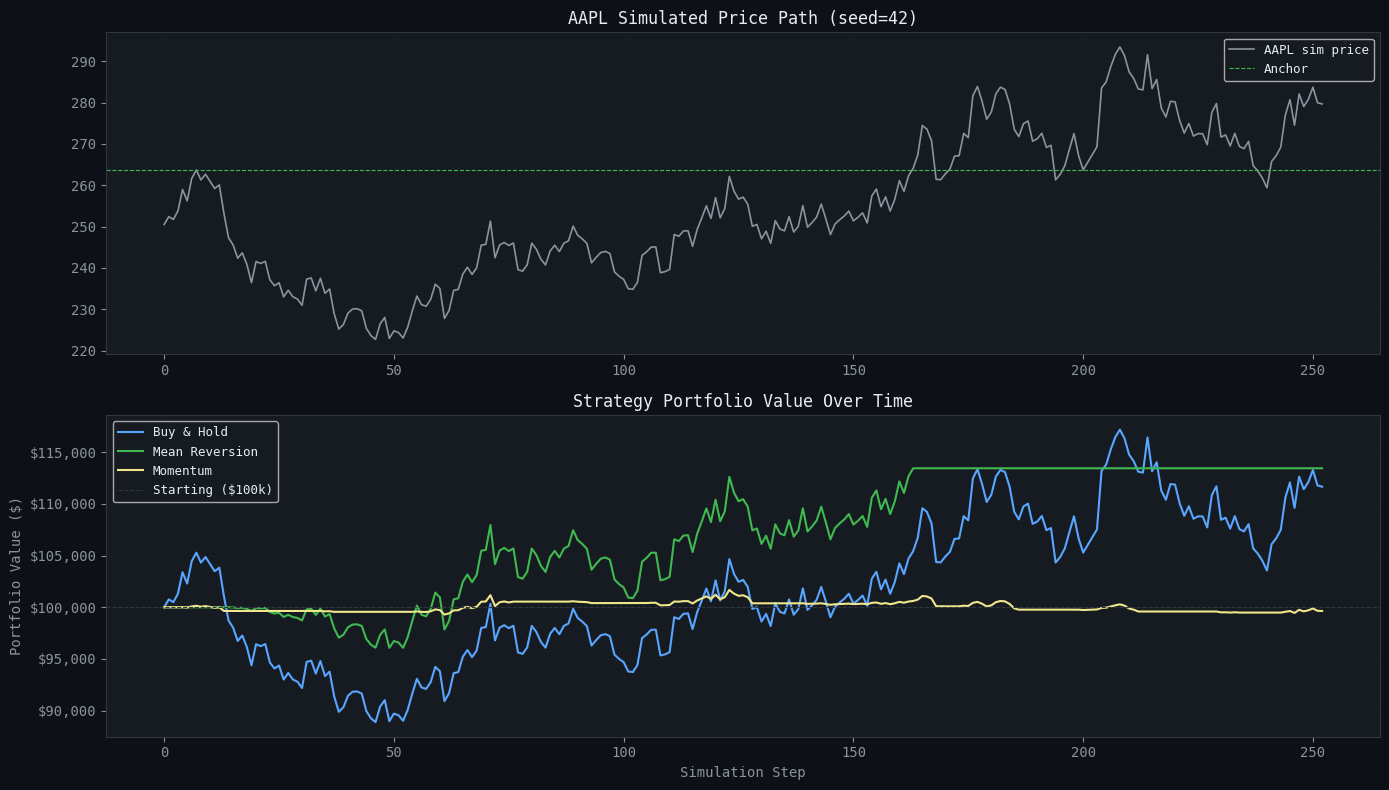

Buy & Hold        : final=$111,650.30  return=+11.65%
Mean Reversion    : final=$113,428.98  return=+13.43%
Momentum          : final=$ 99,639.05  return=-0.36%


In [8]:
# ── 3. Three trading strategy backtests ────────────────────────────────────
#
# Strategy A: Buy & Hold AAPL for 252 sim steps
# Strategy B: Mean-reversion — buy when price > 5% below anchor, sell at anchor
# Strategy C: Momentum — buy when last 5-day return > 2%, sell when < -2%

STARTING_CASH = 100_000
ticker        = 'AAPL'
prices_sim    = simulate_prices(ticker, 252, seed=42)
anchor        = anchors.get(ticker, 100)

def backtest_buy_hold(prices, cash=STARTING_CASH):
    shares = cash / prices[0]
    return [shares * p for p in prices]

def backtest_mean_reversion(prices, anchor, cash=STARTING_CASH):
    portfolio, shares, cur_cash = [cash], 0, cash
    for p in prices[1:]:
        if p < anchor * 0.95 and cur_cash >= p:
            buy = min(10, int(cur_cash / p))
            shares += buy; cur_cash -= buy * p
        elif p >= anchor and shares > 0:
            cur_cash += shares * p; shares = 0
        portfolio.append(cur_cash + shares * p)
    return portfolio

def backtest_momentum(prices, cash=STARTING_CASH, window=5):
    portfolio, shares, cur_cash = [cash], 0, cash
    for i in range(1, len(prices)):
        p = prices[i]
        ret5 = (prices[i] - prices[max(0, i-window)]) / prices[max(0, i-window)]
        if ret5 > 0.02 and cur_cash >= p:
            buy = min(10, int(cur_cash / p))
            shares += buy; cur_cash -= buy * p
        elif ret5 < -0.02 and shares > 0:
            cur_cash += shares * p; shares = 0
        portfolio.append(cur_cash + shares * p)
    return portfolio

bh  = backtest_buy_hold(prices_sim)
mr  = backtest_mean_reversion(prices_sim, anchor)
mom = backtest_momentum(prices_sim)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Price path
axes[0].plot(prices_sim, color='#8b949e', lw=1.2, label=f'{ticker} sim price')
axes[0].axhline(anchor, color='#3fb950', lw=0.8, ls='--', label='Anchor')
axes[0].set_title(f'{ticker} Simulated Price Path (seed=42)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Strategy P&L
axes[1].plot(bh,  color='#58a6ff', lw=1.5, label='Buy & Hold')
axes[1].plot(mr,  color='#3fb950', lw=1.5, label='Mean Reversion')
axes[1].plot(mom, color='#f0e68c', lw=1.5, label='Momentum')
axes[1].axhline(STARTING_CASH, color='#30363d', lw=0.8, ls='--', label='Starting ($100k)')
axes[1].set_title('Strategy Portfolio Value Over Time')
axes[1].set_ylabel('Portfolio Value ($)')
axes[1].set_xlabel('Simulation Step')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_strategy_backtest.png', dpi=120, bbox_inches='tight')
plt.show()

for name, pf in [('Buy & Hold', bh), ('Mean Reversion', mr), ('Momentum', mom)]:
    ret = (pf[-1] - STARTING_CASH) / STARTING_CASH * 100
    print(f'{name:<18}: final=${pf[-1]:>10,.2f}  return={ret:>+.2f}%')

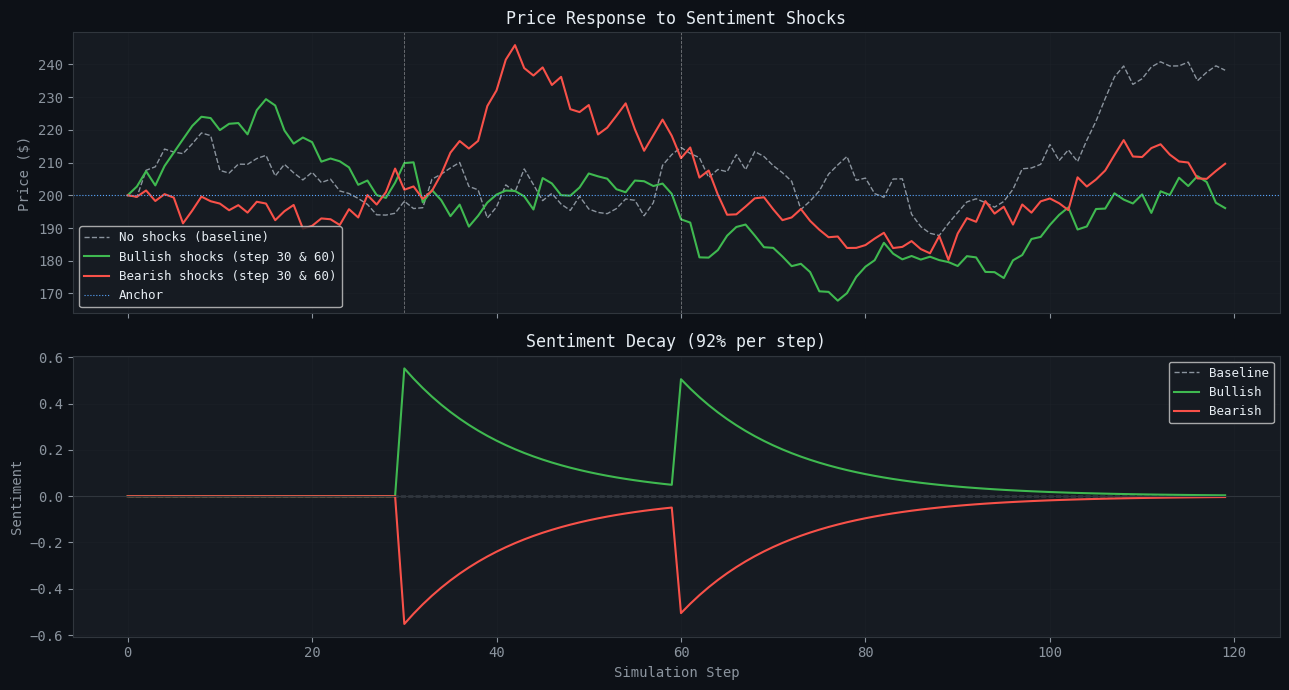

In [9]:
# ── 4. Sentiment shock test ─────────────────────────────────────────────────
def simulate_with_shocks(anchor, sigma=0.02, n=120, shocks=None):
    """Simulate price with explicit sentiment shocks at given steps."""
    shocks     = shocks or {}
    price      = anchor
    sentiment  = 0.0
    prices     = [price]
    sentiments = [sentiment]

    for step in range(1, n):
        if step in shocks:
            sentiment = max(-1, min(1, sentiment + shocks[step]))
        noise     = np.random.normal(0, sigma)
        reversion = 0.015 * (anchor - price) / anchor
        sent_drft = 0.008 * sentiment
        price     = max(0.01, price * (1 + noise + reversion + sent_drft))
        sentiment *= 0.92
        prices.append(price)
        sentiments.append(sentiment)

    return np.array(prices), np.array(sentiments)

np.random.seed(99)
ANCHOR = 200.0
SIGMA  = 0.02

p_base, s_base = simulate_with_shocks(ANCHOR, SIGMA)
p_bull, s_bull = simulate_with_shocks(ANCHOR, SIGMA, shocks={30: +0.6, 60: +0.5})
p_bear, s_bear = simulate_with_shocks(ANCHOR, SIGMA, shocks={30: -0.6, 60: -0.5})

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(p_base, color='#8b949e', lw=1, ls='--', label='No shocks (baseline)')
axes[0].plot(p_bull, color='#3fb950', lw=1.5, label='Bullish shocks (step 30 & 60)')
axes[0].plot(p_bear, color='#f85149', lw=1.5, label='Bearish shocks (step 30 & 60)')
axes[0].axhline(ANCHOR, color='#58a6ff', lw=0.8, ls=':', label='Anchor')
axes[0].axvline(30, color='white', lw=0.6, ls='--', alpha=0.4)
axes[0].axvline(60, color='white', lw=0.6, ls='--', alpha=0.4)
axes[0].set_title('Price Response to Sentiment Shocks')
axes[0].set_ylabel('Price ($)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(s_base, color='#8b949e', lw=1, ls='--', label='Baseline')
axes[1].plot(s_bull, color='#3fb950', lw=1.5, label='Bullish')
axes[1].plot(s_bear, color='#f85149', lw=1.5, label='Bearish')
axes[1].axhline(0, color='#30363d', lw=0.8)
axes[1].set_title('Sentiment Decay (92% per step)')
axes[1].set_ylabel('Sentiment')
axes[1].set_xlabel('Simulation Step')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_sentiment_shocks.png', dpi=120, bbox_inches='tight')
plt.show()